# Experiment 9 — targeted behavioral feature discovery

**Question.** Can a small set of interpretable behavioral representations expose signal that transfers across both E6 model families and alternative validation splits?

**Prior evidence.** E4 promoted only the screen/work-study contrast. Notifications/open, opens/screen-hour, notifications/screen-hour, weekend/daily ratio and gap, entertainment total, and entertainment share were already weak or negative and are not repeated unchanged.

**Held constant.** Raw predictors, the E4 feature, native categorical handling, fold assignments, model seeds, E6 structures and round counts, and the 40/60 blend. **Changed.** Only the declared engineered representation(s).

**Promotion rule.** A candidate must clear a fixed inexpensive screen in both families, improve fixed E6 on seed 42, and transfer positively to the five E8 seeds with a positive paired interval.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks": ROOT = ROOT.parent
REPORTS = ROOT / "reports"
required = ["feature_discovery_candidates.csv", "feature_discovery_screen.csv",
            "feature_discovery_packages.csv", "feature_discovery_confirmation.csv",
            "feature_discovery_analysis.json"]
missing = [name for name in required if not (REPORTS / name).exists()]
assert not missing, f"Missing saved reports: {missing}"
candidates = pd.read_csv(REPORTS / "feature_discovery_candidates.csv")
screen = pd.read_csv(REPORTS / "feature_discovery_screen.csv")
packages = pd.read_csv(REPORTS / "feature_discovery_packages.csv")
confirmation = pd.read_csv(REPORTS / "feature_discovery_confirmation.csv")
analysis = json.loads((REPORTS / "feature_discovery_analysis.json").read_text())
print("Loaded compact E9 reports; this notebook trains no models.")

Loaded compact E9 reports; this notebook trains no models.


## Predeclared hypotheses

Ten features were frozen before their AUCs were evaluated. The raw counts are bounded and only mildly skewed, so a broad log-transform family was not justified. Ratios use safe division, infinities map to missing, and no fitted global preprocessing is introduced.

In [2]:
display(candidates[["feature", "family", "hypothesis", "train_missing_rate", "test_missing_rate", "train_infinite_count"]]
        .style.format({"train_missing_rate": "{:.3%}", "test_missing_rate": "{:.3%}"}))

,feature,family,hypothesis,train_missing_rate,test_missing_rate,train_infinite_count
0,social_media_screen_share,composition,Social-media share may be more informative than absolute hours.,27.353%,23.039%,0
1,gaming_screen_share,composition,Gaming share may distinguish screen-time composition.,26.563%,26.198%,0
2,work_study_screen_share,composition,Work/study share may complement the existing difference feature.,19.952%,19.071%,0
3,unallocated_screen_contrast,composition,Total screen time not represented by three named activities may add signal.,39.045%,38.479%,0
4,leisure_productive_balance,composition,A bounded relative screen/work-study contrast may add scale invariance.,19.952%,19.071%,0
5,weekend_relative_deviation,weekday_weekend,A bounded weekend deviation may be stabler than E4's ratio or raw gap.,25.090%,23.926%,0
6,joint_engagement_intensity,engagement,The geometric mean of notifications and opens may capture joint intensity.,17.832%,17.014%,0
7,social_engagement_load,interaction,Social-media hours and app opens may jointly represent engagement load.,28.126%,22.831%,0
8,cross_context_screen_load,weekday_weekend,Weekday-like and weekend screen levels may interact across contexts.,25.090%,23.926%,0
9,screen_sleep_balance,balance,The difference between screen and sleep hours may expose a behavioral balance.,19.095%,17.474%,0


## Inexpensive development screen

Each candidate is added individually to the E4 feature set and evaluated with the fixed 300-tree E4 LightGBM and XGBoost configurations on seed 42. Advancement requires at least +0.00005 blend AUC, positive deltas in both components, and positive blend deltas on at least three folds.

,LightGBM Δ,XGBoost Δ,Blend AUC,Blend Δ,Positive folds
name,,,,,
unallocated_screen_contrast,+0.000462,+0.000581,0.961870,+0.000544,5
gaming_screen_share,+0.000132,+0.000065,0.961375,+0.000049,4
work_study_screen_share,+0.000081,-0.000021,0.961349,+0.000024,2
joint_engagement_intensity,+0.000095,-0.000035,0.961349,+0.000023,3
screen_sleep_balance,+0.000203,-0.000060,0.961343,+0.000017,2
leisure_productive_balance,-0.000047,-0.000030,0.961291,-0.000035,2
social_media_screen_share,-0.000061,-0.000087,0.961226,-0.000100,1
social_engagement_load,-0.000027,-0.000124,0.961223,-0.000103,3
weekend_relative_deviation,-0.000452,-0.000070,0.961137,-0.000189,1


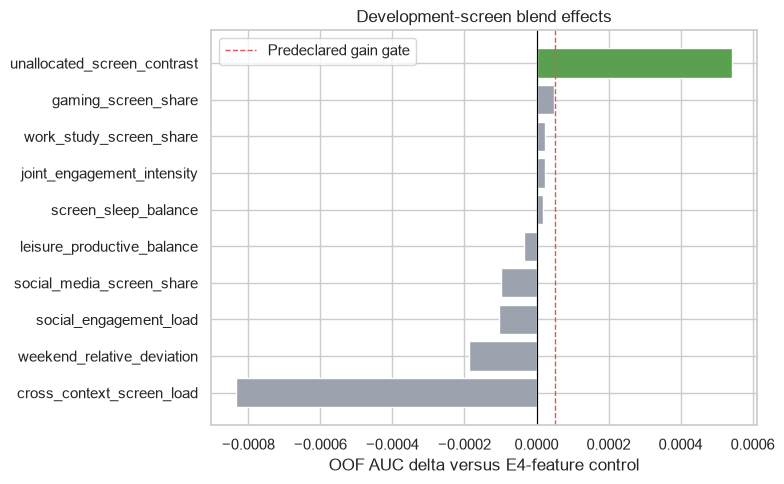

In [3]:
pivot = screen.pivot(index="name", columns="model", values=["oof_auc", "delta_vs_control", "positive_fold_deltas"])
screen_table = pd.DataFrame({
    "LightGBM Δ": pivot["delta_vs_control"]["LightGBM"],
    "XGBoost Δ": pivot["delta_vs_control"]["XGBoost"],
    "Blend AUC": pivot["oof_auc"]["Blend50_50"],
    "Blend Δ": pivot["delta_vs_control"]["Blend50_50"],
    "Positive folds": pivot["positive_fold_deltas"]["Blend50_50"].astype(int),
}).sort_values("Blend Δ", ascending=False)
display(screen_table.style.format({column: "{:+.6f}" for column in ["LightGBM Δ", "XGBoost Δ", "Blend Δ"]}
                           | {"Blend AUC": "{:.6f}"}))
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#59A14F" if value >= 0.00005 else "#9CA3AF" for value in screen_table["Blend Δ"]]
ax.barh(screen_table.index[::-1], screen_table["Blend Δ"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=.8)
ax.axvline(.00005, color="#E15759", linestyle="--", linewidth=1, label="Predeclared gain gate")
ax.set(title="Development-screen blend effects", xlabel="OOF AUC delta versus E4-feature control", ylabel="")
ax.legend()
plt.tight_layout(); plt.show()

Only `unallocated_screen_contrast` clears the gate: +0.000462 for LightGBM, +0.000581 for XGBoost, and +0.000544 for the 50/50 blend, positive on all five folds. Gaming share is directionally positive but misses the declared blend threshold; all other hypotheses fail component agreement, magnitude, or fold consistency.

The selected feature is `daily_screen_time_hours - social_media_hours - gaming_hours - work_study_hours`. It is best understood as a residual contrast among recorded time variables—not a literal or causal measure of unobserved activity. No multi-feature package is justified because no second feature clears the gate.

## Fixed E6 confirmation

The single feature is frozen before confirmation. Both models use their deployed E6 round counts and the blend remains 40% LightGBM / 60% XGBoost. A newly fitted fixed-round seed-42 control provides the direct comparison; the historical 0.964289 score used fold-local early stopping and is retained as context.

In [4]:
seed42 = confirmation[confirmation["fold_seed"] == 42][["model", "control_auc", "oof_auc", "delta_vs_control", "positive_fold_deltas"]]
display(seed42.style.format({"control_auc": "{:.6f}", "oof_auc": "{:.6f}", "delta_vs_control": "{:+.6f}"}))

,model,control_auc,oof_auc,delta_vs_control,positive_fold_deltas
0,LightGBM,0.963412,0.963935,+0.000523,5
1,XGBoost,0.963991,0.964477,+0.000486,5
2,Blend40_60,0.964291,0.964777,+0.000485,5


The feature improves fixed E6 LightGBM by +0.000523, XGBoost by +0.000486, and the matched 40/60 blend by +0.000485. Every component's fold delta is positive, so the effect is not attributable to one model family. The candidate blend reaches **0.964777** on seed 42.

## Independent split confirmation

The exact frozen package is evaluated on E8's five seeds, reusing E8 control predictions. Inference treats five seeds—not 25 dependent folds—as the paired units.

,fold_seed,control_auc,oof_auc,delta_vs_control,positive_fold_deltas
5,7,0.964237,0.964767,+0.000530,5
8,21,0.964224,0.964771,+0.000547,5
11,84,0.964213,0.964738,+0.000525,5
14,123,0.964213,0.964741,+0.000528,5
17,2026,0.964232,0.964726,+0.000494,5


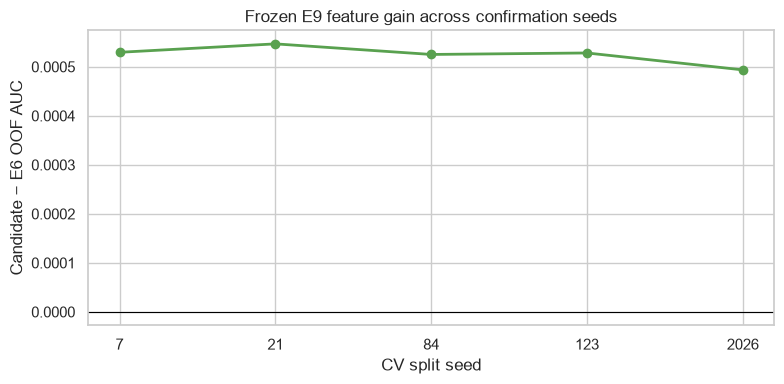

,mean_difference,median_difference,std_difference,min_difference,max_difference,wins,ties,losses,paired_t_ci_95_lower,paired_t_ci_95_upper,seed_bootstrap_ci_95_lower,seed_bootstrap_ci_95_upper,seed_bootstrap_positive,n_independent_seeds,bootstrap_resamples,bootstrap_seed
0,+0.000525,+0.000528,0.000019,0.000494,0.000547,5,0,0,0.000501,0.000549,+0.000508,+0.000539,1.000000,5,10000,42


In [5]:
repeated = confirmation[(confirmation["model"] == "Blend40_60") & (confirmation["fold_seed"] != 42)][
    ["fold_seed", "control_auc", "oof_auc", "delta_vs_control", "positive_fold_deltas"]
]
display(repeated.style.format({"control_auc": "{:.6f}", "oof_auc": "{:.6f}", "delta_vs_control": "{:+.6f}"}))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(repeated["fold_seed"].astype(str), repeated["delta_vs_control"], marker="o", linewidth=2, color="#59A14F")
ax.axhline(0, color="black", linewidth=.8)
ax.set(title="Frozen E9 feature gain across confirmation seeds", xlabel="CV split seed", ylabel="Candidate − E6 OOF AUC")
plt.tight_layout(); plt.show()
pd.DataFrame([analysis["repeated_seed_comparison"]]).style.format({
    "mean_difference": "{:+.6f}", "median_difference": "{:+.6f}",
    "std_difference": "{:.6f}", "seed_bootstrap_ci_95_lower": "{:+.6f}",
    "seed_bootstrap_ci_95_upper": "{:+.6f}",
})

The blend improves on all five seeds by a mean **+0.000525** AUC (median +0.000528; SD 0.000019). The seed-bootstrap 95% interval is **[+0.000508, +0.000539]**, positive in every resample. Both component models also improve on every seed. Seed 42's +0.000485 gain is below every added-seed gain, so it was not unusually favorable.

## Limitations and promotion decision

Ten candidates share the development folds, so selection bias is not eliminated; the frozen cross-seed confirmation mitigates rather than erases it. Five seeds remain a small independent sample, and their narrow interval should not be generalized beyond this repeated-CV design. The target-generation process is unknown, so the new representation is described only as a predictive contrast, not a causal construct.

**Final champion:** E9 adds the single residual screen-time contrast to E6 and retains the same 40/60 ensemble. It reaches **0.964777 matched seed-42 OOF AUC**, transfers to both families and all five additional seeds, and scored **0.96621 public Kaggle AUC** after the local decision. The repeated-validation estimate (+0.000525 over E6) closely matches the public improvement (+0.00054), which is encouraging external consistency; the public leaderboard remains one holdout rather than statistical confirmation.